# Trajectory Averaging Tutorial

This notebook demonstrates frame-averaged structural analysis in **amorphouspy** using a 101-frame sodium borosilicate glass trajectory (`NaBSiO_glass_trajectory.extxyz`).

Topics covered:
1. Loading a multi-frame trajectory
2. Individual analysis functions — RDF, S(q), Q<sup>n</sup>, bond angles, rings — each with error bands
3. Effect of frame count on statistical uncertainty

In [1]:
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np

from ase.io import read

import amorphouspy as am

## 1. Load the trajectory

`ase.io.read` with `index=":"` returns a `list[Atoms]` — one entry per frame. The 101 frames here come from an equilibrated NVT run at 300 K after a melt-quench cycle.

In [2]:
frames = read("data/NaBSiO_glass_trajectory.extxyz", index=":")

print(f"Frames loaded : {len(frames)}")
print(f"Atoms per frame: {len(frames[0])}")


counts = Counter(frames[0].get_chemical_symbols())
total = sum(counts.values())
print("Composition   :", {k: f"{v:.1f}" for k, v in sorted(counts.items())})

Frames loaded : 101
Atoms per frame: 999
Composition   : {'B': '90.0', 'Na': '92.0', 'O': '605.0', 'Si': '212.0'}


## 2. Individual analysis functions with error bands

Each low-level function accepts `frame_averaging=True`. Pass a `list[Atoms]` and the return signature extends with `_mean` / `_sem` counterparts for every output array.

### 2.1 Radial distribution functions (RDF)

With `frame_averaging=True` the return signature extends to
```
(r, rdfs_mean, cumcn_mean, rdfs_sem, cumcn_sem)
```

In [3]:
r, rdfs_mean, cumcn_mean, rdfs_sem, cumcn_sem = am.compute_rdf(
    frames,
    r_max=8.0,
    n_bins=500,
    frame_averaging=True,
)

# Show which pairs are available
print("Pairs computed:", list(rdfs_mean.keys()))

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Pairs computed: [(5, 5), (5, 8), (5, 11), (5, 14), (8, 8), (8, 11), (8, 14), (11, 11), (11, 14), (14, 14)]


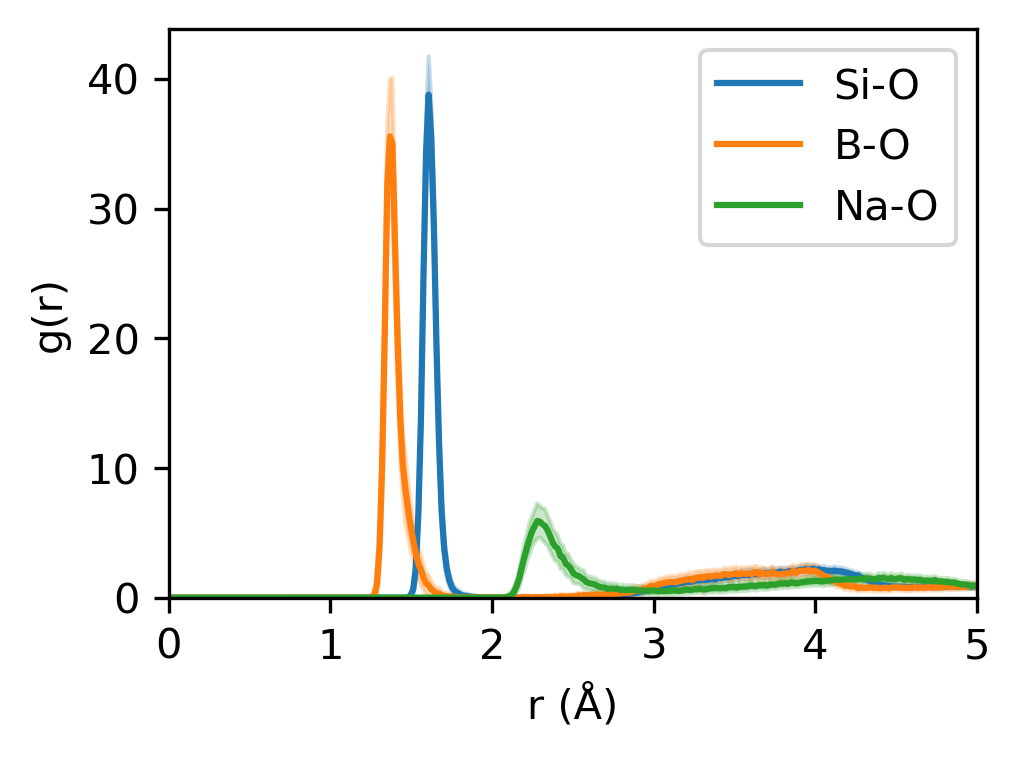

In [4]:
# Keys use sorted atomic numbers (lower Z first): Si=14, O=8, B=5, Na=11
pairs_to_plot = [(8, 14), (5, 8), (8, 11)]  # Si-O, B-O, Na-O
pair_labels = {(8, 14): "Si-O", (5, 8): "B-O", (8, 11): "Na-O"}

fig, ax = plt.subplots(figsize=(3.5, 3.5 / 1.333), dpi=300)
for pair in pairs_to_plot:
    if pair not in rdfs_mean:
        continue
    g_mean = np.array(rdfs_mean[pair])
    g_sem = np.array(rdfs_sem[pair]) * np.sqrt(len(frames))  # SEM = std/sqrt(N), this show the std not the SEM
    label = pair_labels[pair]
    (line,) = ax.plot(r, g_mean, label=label)
    ax.fill_between(r, g_mean - g_sem, g_mean + g_sem, alpha=0.25, color=line.get_color())

ax.set_xlim(0, 5)
ax.set_ylim(0, None)
ax.set_xlabel("r (Å)")
ax.set_ylabel("g(r)")
ax.legend()
plt.tight_layout()
plt.show()

### 2.2 Structure factor S(q)

Return signature: `(q, sq_mean, partials_mean, sq_sem, partials_sem)`

/Users/achrafatila/Documents/Workflows/amorphouspy/amorphouspy/src/amorphouspy/analysis/structure_factor.py:339: UserWarning: r_max=15.0000 Å exceeds half the smallest perpendicular cell height (13.2294 Å). r_max has been automatically adjusted to 13.0 Å (largest integer not exceeding the limit).
  r, rdfs, _, _rdfs_sem, _cumcn_sem = compute_rdf(structure, r_max=r_max, n_bins=n_bins, type_pairs=type_pairs)


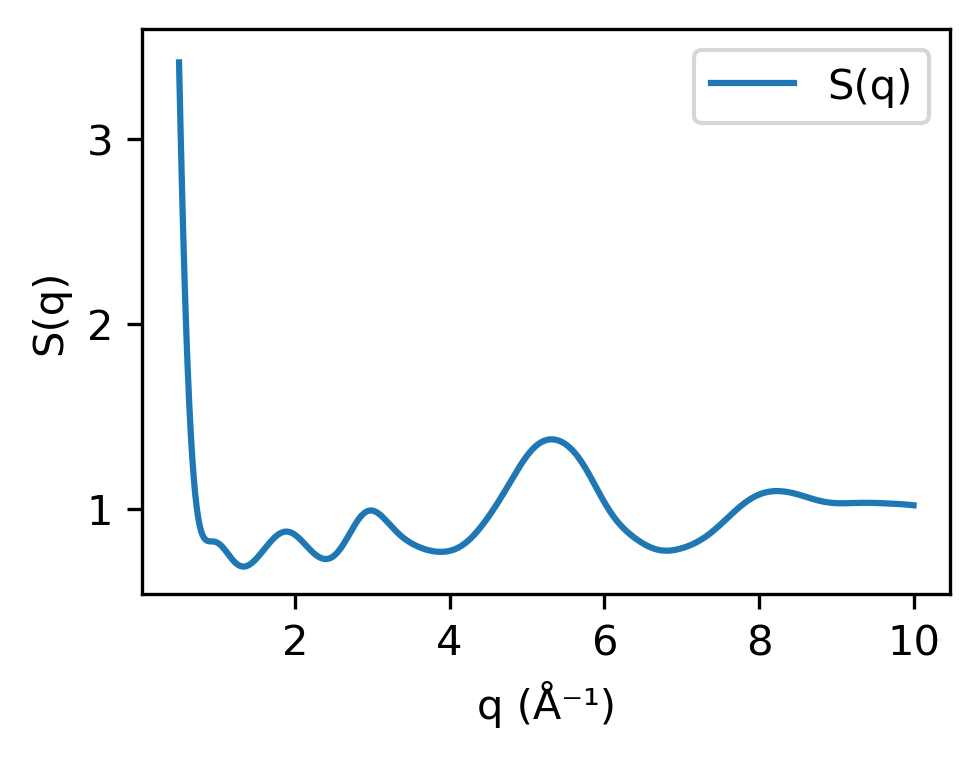

In [5]:
q, sq_mean, partials_mean, sq_sem, partials_sem = am.compute_structure_factor(
    frames,
    q_min=0.5,
    q_max=10.0,
    r_max=15.0,
    n_q=500,
    frame_averaging=True,
)

sq_mean_arr = np.array(sq_mean)
sq_sem_arr = np.array(sq_sem) * np.sqrt(len(frames))  # SEM = std/sqrt(N), this show the std not the SEM

fig, ax = plt.subplots(figsize=(3.5, 3.5 / 1.333), dpi=300)
ax.plot(q, sq_mean_arr, label="S(q)")
ax.fill_between(q, sq_mean_arr - sq_sem_arr, sq_mean_arr + sq_sem_arr, alpha=0.25)
ax.set_xlabel("q (Å⁻¹)")
ax.set_ylabel("S(q)")
ax.legend()
plt.tight_layout()
plt.show()

### 2.3 Q<sup>n</sup> speciation

Return signature: `(total_qn_mean, partial_qn_mean, total_qn_sem, partial_qn_sem)`

The cutoff is the Si-O first-shell cutoff read from the RDF minimum.

In [6]:
# Determine Si-O cutoff from the averaged RDF (pair key: lower Z first, so O=8 < Si=14)
si_o_rdf = np.array(rdfs_mean.get((8, 14), []))
si_o_cutoff = am.find_rdf_minimum(r, si_o_rdf) if len(si_o_rdf) else 2.0
print(f"Si-O cutoff: {si_o_cutoff:.3f} Å")

total_qn_mean, partial_qn_mean, total_qn_sem, partial_qn_sem = am.compute_qn(
    frames,
    cutoff=si_o_cutoff,
    former_types=[14],  # Si
    o_type=8,
    frame_averaging=True,
)

print("\nFormer Qn distribution (mean ± SEM):")
for n in sorted(total_qn_mean):
    print(f"  Q{n}: {total_qn_mean[n]:.3f} ± {total_qn_sem[n]:.3f}")

Si-O cutoff: 1.816 Å

Former Qn distribution (mean ± SEM):
  Q0: 2.000 ± 0.000
  Q1: 14.030 ± 0.017
  Q2: 60.188 ± 0.080
  Q3: 90.228 ± 0.118
  Q4: 44.059 ± 0.112
  Q5: 1.495 ± 0.087
  Q6: 0.000 ± 0.000


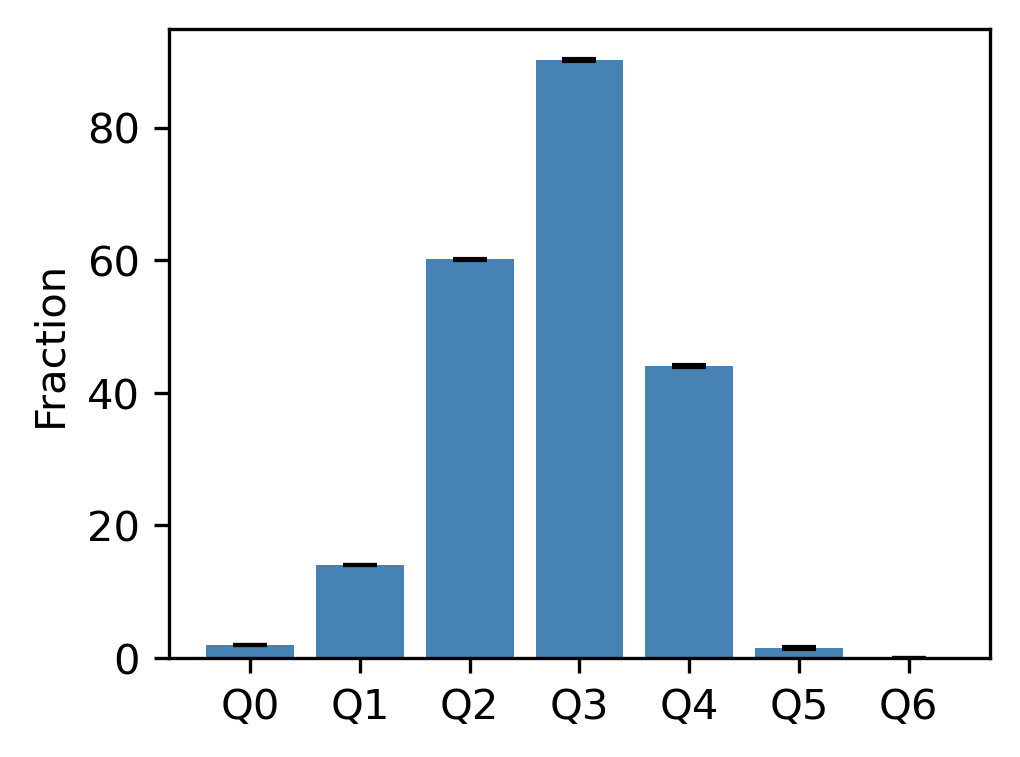

In [7]:
ns = sorted(total_qn_mean.keys())
means = [total_qn_mean[n] for n in ns]
errors = [total_qn_sem[n] for n in ns]

fig, ax = plt.subplots(figsize=(3.5, 3.5 / 1.333), dpi=300)
ax.bar([f"Q{n}" for n in ns], means, yerr=errors, capsize=4, color="steelblue")
ax.set_ylabel("Fraction")
plt.tight_layout()
plt.show()

### 2.4 Bond angle distribution

Return signature: `(bin_centers, hist_mean, hist_sem)`

Here we compute the O-Si-O intra-tetrahedral angle (`center_type=14`, `neighbor_type=8`), which should peak near 109.5°.

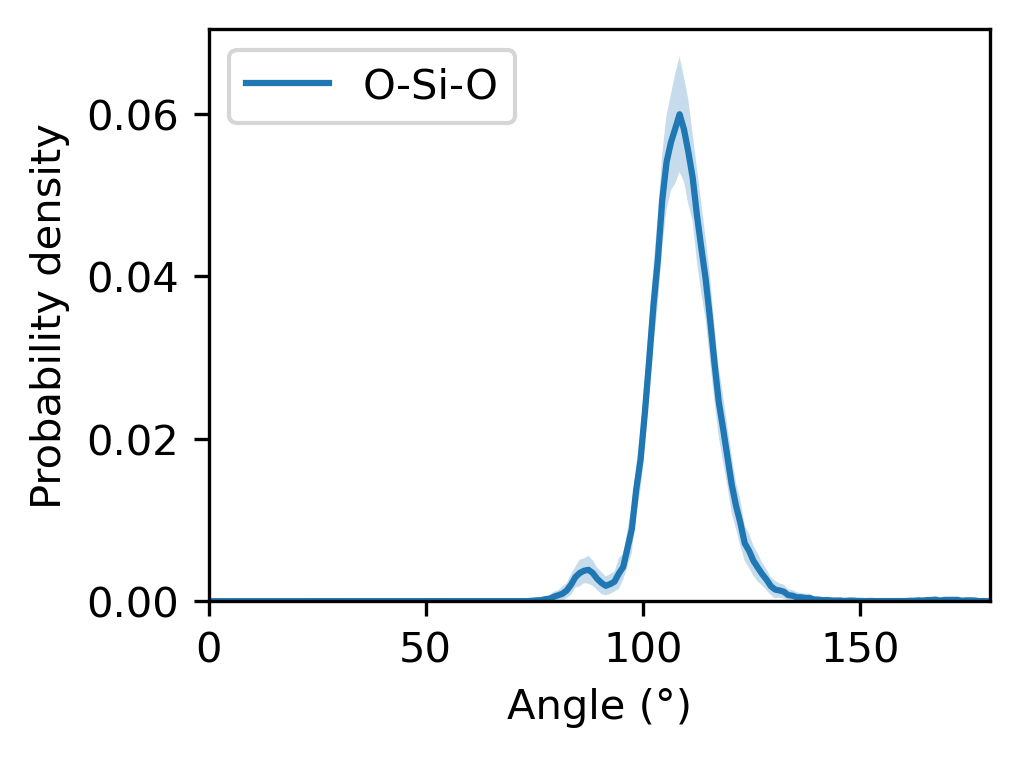

In [8]:
# O-Si-O angle: center atom is Si (14), neighbor atoms are O (8)
bin_centers, hist_mean, hist_sem = am.compute_angles(
    frames,
    center_type=14,
    neighbor_type=8,
    cutoff=si_o_cutoff,
    frame_averaging=True,
)

hist_mean_arr = np.array(hist_mean)
hist_sem_arr = np.array(hist_sem) * np.sqrt(len(frames))  # SEM = std/sqrt(N), this show the std not the SEM

fig, ax = plt.subplots(figsize=(3.5, 3.5 / 1.333), dpi=300)
ax.plot(bin_centers, hist_mean_arr, label="O-Si-O")
ax.fill_between(bin_centers, hist_mean_arr - hist_sem_arr, hist_mean_arr + hist_sem_arr, alpha=0.25)
ax.set_xlim(0, 180)
ax.set_ylim(0, None)
ax.set_xlabel("Angle (°)")
ax.set_ylabel("Probability density")
ax.legend()
plt.tight_layout()
plt.show()

### 2.5 Ring statistics

Return signature: `(histogram_mean, mean_size_mean, histogram_sem, mean_size_sem)`

Finding rings: 100%|██████████| 548/548 [00:00<00:00, 7462.47edge/s]

Mean ring size: 4.93 ± 0.00 members


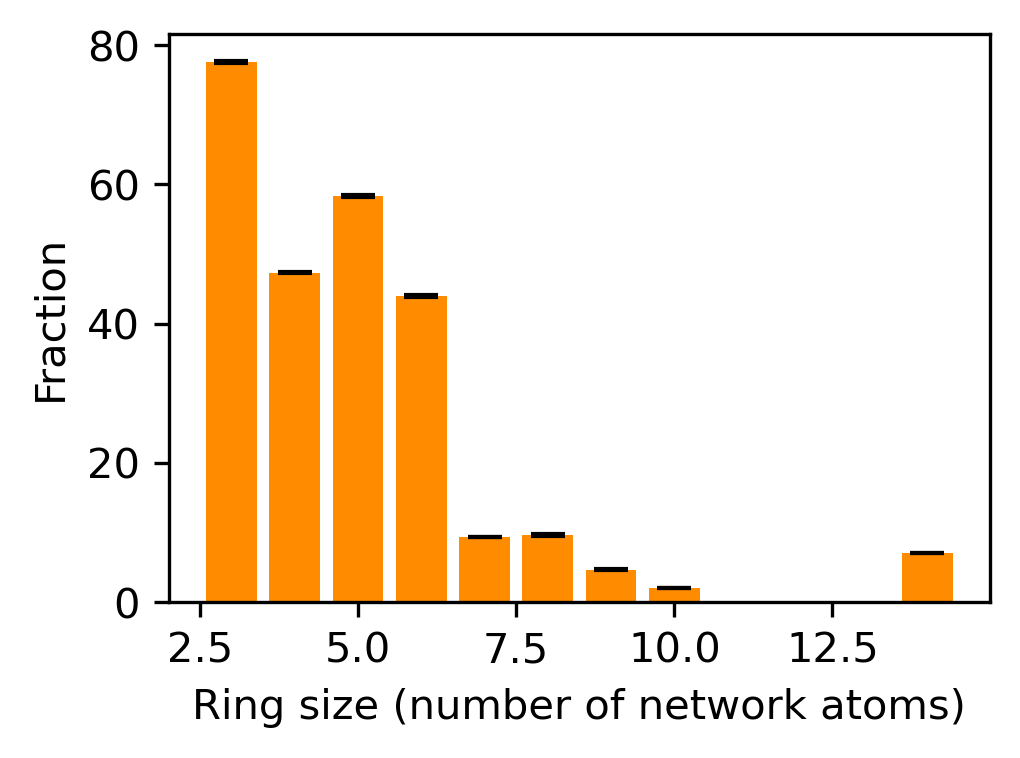

In [9]:
bond_lengths = am.generate_bond_length_dict(
    frames[0], specific_cutoffs={("Si", "O"): 2.0, ("B", "O"): 1.8}, default_cutoff=0.0
)

histogram_mean, mean_size_mean, histogram_sem, mean_size_sem = am.compute_guttmann_rings(
    frames,
    bond_lengths=bond_lengths,
    frame_averaging=True,
)

print(f"Mean ring size: {mean_size_mean:.2f} ± {mean_size_sem:.2f} members")

ring_sizes = sorted(histogram_mean.keys())
h_mean = [histogram_mean[s] for s in ring_sizes]
h_sem = [histogram_sem.get(s, 0.0) for s in ring_sizes]

fig, ax = plt.subplots(figsize=(3.5, 3.5 / 1.333), dpi=300)
ax.bar(ring_sizes, h_mean, yerr=h_sem, capsize=4, color="darkorange")
ax.set_xlabel("Ring size (number of network atoms)")
ax.set_ylabel("Fraction")
plt.tight_layout()
plt.show()

## 3. Effect of frame count on uncertainty

The standard error of the mean shrinks as $1/\sqrt{N}$. We can verify this empirically by computing the total S(q) standard error of the mean for increasing numbers of frames.

In [10]:
frame_counts = [5, 10, 20, 50, 101]
mean_sems = []

for n in frame_counts:
    _, _, _, sq_sem_n, _ = am.compute_structure_factor(
        frames[:n],
        q_min=0.5,
        q_max=15.0,
        n_q=500,
        frame_averaging=True,
    )
    mean_sems.append(float(np.mean(np.abs(sq_sem_n))))
    print(f"  N={n:>3d}  mean |SEM| = {mean_sems[-1]:.5f}")

  N=  5  mean |SEM| = 0.00204
  N= 10  mean |SEM| = 0.00141
  N= 20  mean |SEM| = 0.00099
  N= 50  mean |SEM| = 0.00067
  N=101  mean |SEM| = 0.00050


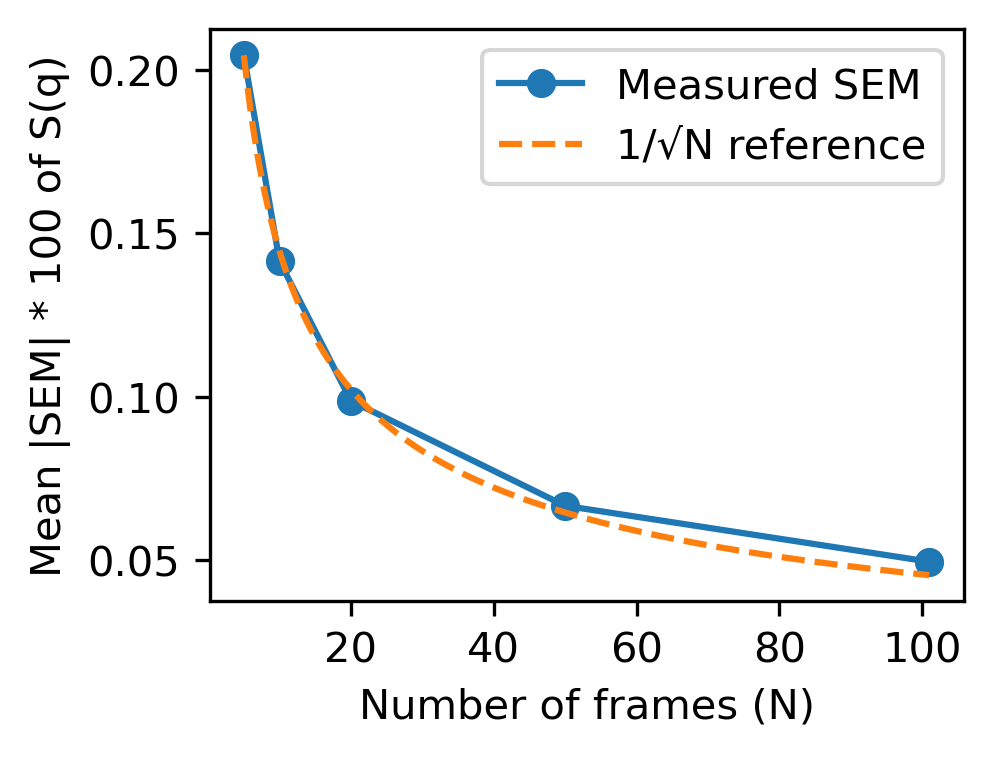

In [11]:
ref_scale = mean_sems[0] * np.sqrt(frame_counts[0])
ref_x = np.linspace(frame_counts[0], frame_counts[-1], 200)

fig, ax = plt.subplots(figsize=(3.5, 3.5 / 1.333), dpi=300)
ax.plot(frame_counts, np.asarray(mean_sems) * 100, "o-", label="Measured SEM")
ax.plot(ref_x, (ref_scale / np.sqrt(ref_x)) * 100, "--", label="1/√N reference")
ax.set_xlabel("Number of frames (N)")
ax.set_ylabel("Mean |SEM| * 100 of S(q)")
ax.legend()
plt.tight_layout()
plt.show()

The measured standard error of the mean closely follows the $1/\sqrt{N}$ curve, confirming that frames are effectively decorrelated and that the averaging is working as expected.

---

## Summary

| What | How |
|---|---|
| Load trajectory | `ase.io.read(path, index=":")` → `list[Atoms]` |
| Individual function with uncertainty | add `frame_averaging=True`; return signature gains `_mean` / `_sem` fields |
| Plot mean ± standard error of the mean ribbon | concatenate forward/reverse arrays and use `fill="toself"` |
| How many frames | 20-100 is usually sufficient; check that standard error of the mean < measurement noise |
